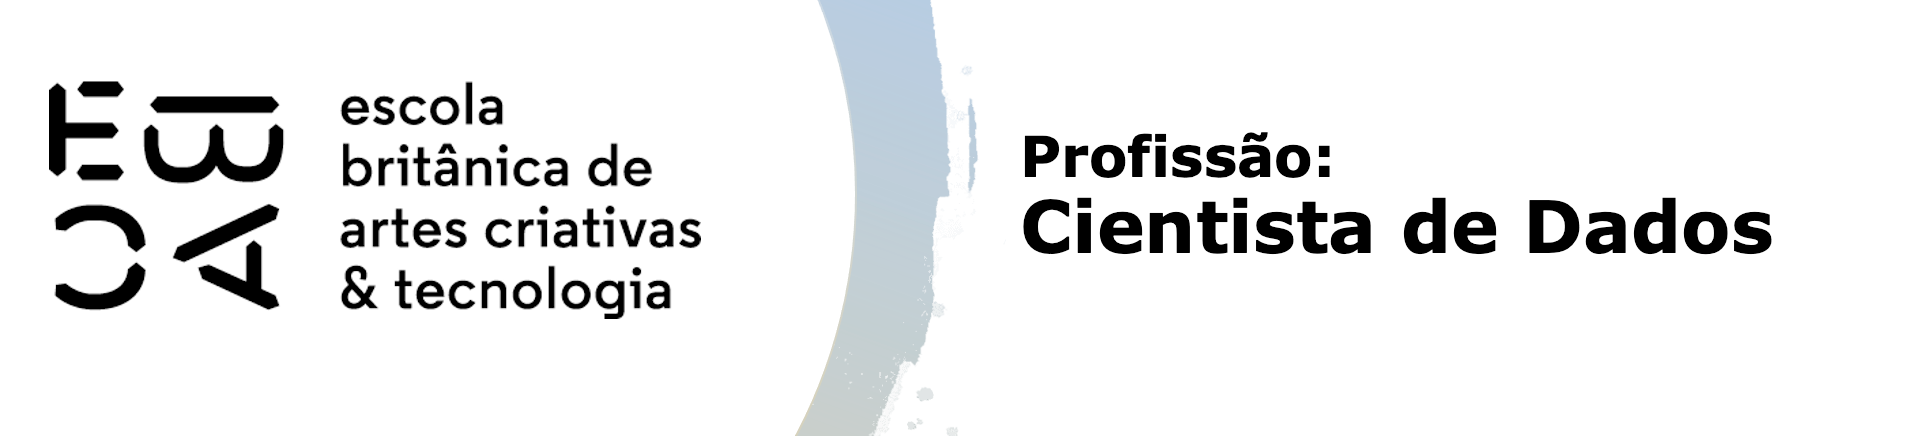

# Tarefa

Carregue a base ```NFP.ftr```. Essa base é proveniente do projeto #AMABiliDados, e contém dados da nota fiscal paulista cadastrados para doação automática para a AMA, Associação de Amigos do Autista. 

A *Nota Fiscal Paulista* é um programa de incentivo do governo do estado de São Paulo, que retorna um pedacinho do ICMS ao consumidor sempre que solicita o registro do seu CPF na nota. Nesse programa, o contribuinte pode direcionar seus créditos a uma ONG, e quando faz isso, sempre que faz esse consumidor cadastrado faz uma compra, os créditos de notas emitidas pelo mesmo estabelecimento não identificadas (notas sem CPF) são "arrastados" para a ONG na forma de uma doação.

Clique no link, caso queira saber mais sobre a [AMA](https://www.ama.org.br/site/).<br>
Clique no link, caso queira saber como o cidadão pode ser um [doador da NFP](https://doacao1.ama.org.br/sitenfp).

Essa base possui dados das notas cujos contribuintes direcionaram seus créditos à AMA. Seus campos estão descritos abaixo:

|Campo|Descrição|
|:-|:-|
|CNPJ emit.| CNPJ do emitente da nota|
|Emitente| Nome fantasia do emitente da nota|
|No.| Número da nota fiscal|
|Data Emissão| Data de emissão da nota fiscal|
|Valor NF| Valor da nota fiscal|
|Data Registro| Data de registro no sistema da NFP|
|Créditos| Valor dos créditos (doação)|
|Situação do Crédito| Se o crédito já foi pago, está sendo processado etc.|
|Ano| Ano da emissão da nota|
|Semestre| Semestre da emissão da nota|
|Retorno| Valor do crédito dividido pelo valor da nota|
|flag_credito| Indicadora se a nota possui crédito positivo|
|categoria| Categorização da nota |

**OBJETIVO:** Algumas notas não dão retorno, o que pode ocorrer por diversos motivos, um deles seria a ocorrência de produtos não incentivados como cigarros e bebidas alcólicas. O nosso objetivo é tentar prever que tipo de nota tem maior ou menor propensão a fornecer créditos.

**Observação**: Esta é uma base real, havendo características de acordo. Pode haver uma variabilidade difícil de explicar, em parte por causa de uma freqüência de notas inconstante no tempo (por diversos motivos), em parte por haverem informações importantes, protegidas pela LGPD, não constantes na base, que pode interferir no crédito gerado, o que vai ocasionar uma variabilidade difícil de se explicar. *Welcome to the jungle*, A vida real é assim :)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregando a base

try:
    df = pd.read_feather('NFP.ftr')
except FileNotFoundError:
    df = pd.read_pickle('base_nfp.pkl')

print('Quantidade de linhas e colunas da base:', df.shape)
df.head()

Quantidade de linhas e colunas da base: (187646, 13)


,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes


## Análise da probabilidade de retorno

Considere somente os dados de janeiro de 2020 em diante para esta análise.

- Analise a proporção de notas que tiveram retorno>0 por categoria de estabelecimento. Esta análise pode ser por tabela ou gráfico.

Proporção de notas com retorno positivo por categoria:


,qtd_notas,qtd_retorno_positivo,prob_retorno_positivo
categoria,,,
Restaurantes,2179,1626,0.746214
Alimentos,5050,3442,0.681584
Mercado,27558,13177,0.478155
Construção,16047,7523,0.468810
não definido,18407,6689,0.363394
Farmácia,10189,3582,0.351556
Auto posto,540,135,0.250000
Vestuário,1920,443,0.230729
Varejo,5066,701,0.138373


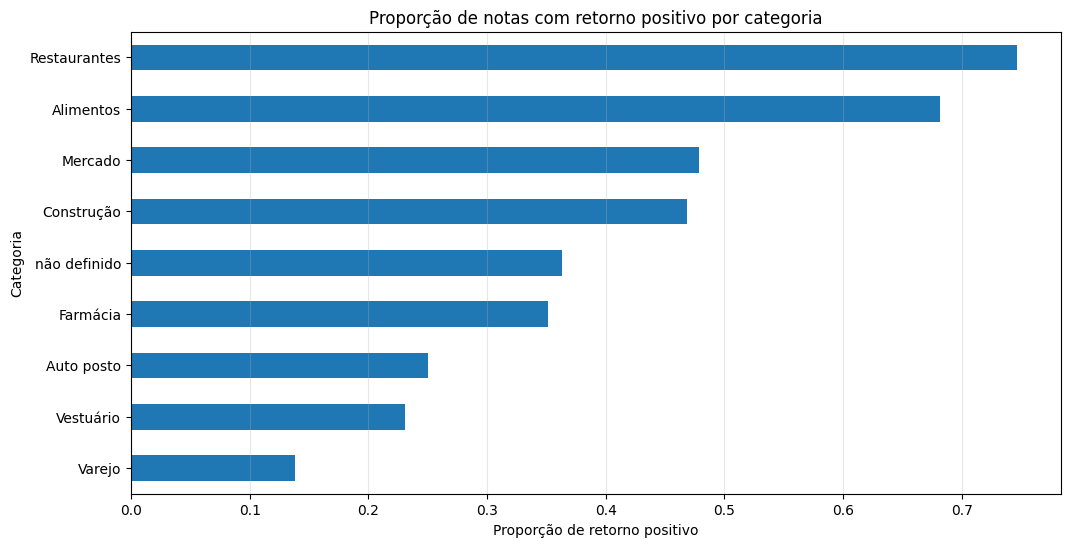

In [6]:
# Converter a coluna de data para o formato datetime
df['Data Emissão'] = pd.to_datetime(df['Data Emissão'])

# Filtrar somente notas emitidas a partir de janeiro de 2020
df_2020 = df[df['Data Emissão'] >= '2020-01-01'].copy()

# Criar variável indicadora do evento: retorno maior que zero
df_2020['retorno_positivo'] = df_2020['Retorno'] > 0

# Calcular a proporção de notas com retorno positivo por categoria
prob_retorno = (
    df_2020
    .groupby('categoria')
    .agg(
        qtd_notas=('retorno_positivo', 'count'),
        qtd_retorno_positivo=('retorno_positivo', 'sum'),
        prob_retorno_positivo=('retorno_positivo', 'mean')
    )
    .sort_values(by='prob_retorno_positivo', ascending=False)
)

print('Proporção de notas com retorno positivo por categoria:')
display(prob_retorno.head(10))

# Gráfico da probabilidade de retorno positivo por categoria
plt.figure(figsize=(12, 6))
prob_retorno['prob_retorno_positivo'].sort_values().plot(kind='barh')
plt.title('Proporção de notas com retorno positivo por categoria')
plt.xlabel('Proporção de retorno positivo')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Cálculo do WOE

- Calcule o WOE das categorias, sendo que o evento em questão é a nota ter retorno>0.
- Analise este WOE por tabela e por gráfico.

Tabela de WOE por categoria:


,eventos,total,nao_eventos,dist_eventos,dist_nao_eventos,WOE
categoria,,,,,,
Restaurantes,1626,2179,553,0.043580,0.011150,1.363175
Alimentos,3442,5050,1608,0.092237,0.032402,1.046147
Mercado,13177,27558,14381,0.353071,0.289701,0.197819
Construção,7523,16047,8524,0.201581,0.171718,0.160338
não definido,6689,18407,11718,0.179235,0.236058,-0.275379
Farmácia,3582,10189,6607,0.095988,0.133102,-0.326894
Auto posto,135,540,405,0.003631,0.008168,-0.810898
Vestuário,443,1920,1477,0.011883,0.029763,-0.918158
Varejo,701,5066,4365,0.018796,0.087939,-1.543016


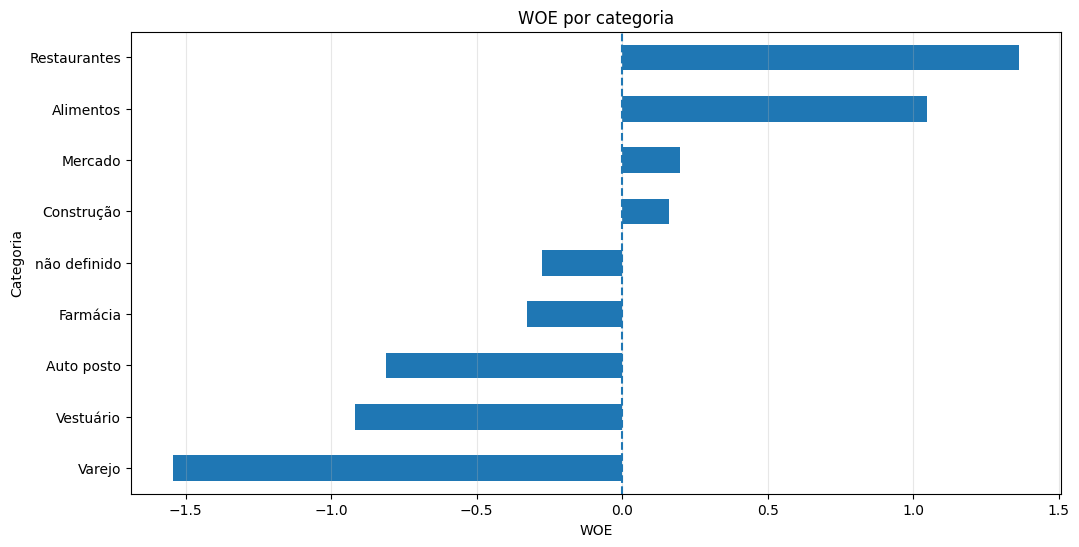

In [7]:
# Cálculo do WOE
# Evento: nota com retorno positivo
# Não evento: nota sem retorno positivo

tab_woe = (
    df_2020
    .groupby('categoria')
    .agg(
        eventos=('retorno_positivo', 'sum'),
        total=('retorno_positivo', 'count')
    )
)

tab_woe['nao_eventos'] = tab_woe['total'] - tab_woe['eventos']

# Totais gerais
total_eventos = tab_woe['eventos'].sum()
total_nao_eventos = tab_woe['nao_eventos'].sum()

# Suavização para evitar divisão por zero, caso alguma categoria não tenha evento ou não evento
tab_woe['dist_eventos'] = (tab_woe['eventos'] + 0.5) / (total_eventos + 0.5 * tab_woe.shape[0])
tab_woe['dist_nao_eventos'] = (tab_woe['nao_eventos'] + 0.5) / (total_nao_eventos + 0.5 * tab_woe.shape[0])

tab_woe['WOE'] = np.log(tab_woe['dist_eventos'] / tab_woe['dist_nao_eventos'])

tab_woe = tab_woe.sort_values(by='WOE', ascending=False)

print('Tabela de WOE por categoria:')
display(tab_woe.head(10))

# Gráfico do WOE por categoria
plt.figure(figsize=(12, 6))
tab_woe['WOE'].sort_values().plot(kind='barh')
plt.title('WOE por categoria')
plt.xlabel('WOE')
plt.ylabel('Categoria')
plt.axvline(0, linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Cálculo do *Information Value*

Calcule o *IV* dessa variável.

In [8]:
# Cálculo do Information Value da variável categoria
tab_woe['IV_categoria'] = (tab_woe['dist_eventos'] - tab_woe['dist_nao_eventos']) * tab_woe['WOE']

iv_total = tab_woe['IV_categoria'].sum()

tab_iv = tab_woe.sort_values(by='IV_categoria', ascending=False)

print('Information Value total da variável categoria:', round(iv_total, 4))
tab_iv.head(10)

Information Value total da variável categoria: 0.2787


,eventos,total,nao_eventos,dist_eventos,dist_nao_eventos,WOE,IV_categoria
categoria,,,,,,,
Varejo,701,5066,4365,0.018796,0.087939,-1.543016,0.106689
Alimentos,3442,5050,1608,0.092237,0.032402,1.046147,0.062596
Restaurantes,1626,2179,553,0.043580,0.011150,1.363175,0.044208
Vestuário,443,1920,1477,0.011883,0.029763,-0.918158,0.016417
não definido,6689,18407,11718,0.179235,0.236058,-0.275379,0.015648
Mercado,13177,27558,14381,0.353071,0.289701,0.197819,0.012536
Farmácia,3582,10189,6607,0.095988,0.133102,-0.326894,0.012132
Construção,7523,16047,8524,0.201581,0.171718,0.160338,0.004788
Auto posto,135,540,405,0.003631,0.008168,-0.810898,0.003680


## Conclua

Não se esqueça de registrar suas conclusões em uma célula de texto. <font color='red'>**Sugestão:**</font> tente alterar a cor da fonte nesta célula para diferenciá-la das demais.


<font color='darkblue'>

## Conclusão

A análise foi realizada considerando somente as notas fiscais emitidas a partir de janeiro de 2020, utilizando a variável `categoria` para verificar se determinadas categorias de estabelecimento apresentam maior ou menor propensão de gerar retorno positivo.

Pela análise da proporção de retorno, observa-se que a probabilidade de retorno não é igual entre as categorias. As categorias **Restaurantes** e **Alimentos** apresentaram os maiores percentuais de retorno positivo, aproximadamente 75% e 68%, respectivamente. Em seguida aparecem **Mercado** e **Construção**, com proporções intermediárias, próximas de 48% e 47%. Por outro lado, as categorias **Varejo**, **Vestuário** e **Auto posto** apresentaram as menores proporções de retorno positivo, indicando menor associação com notas que geram retorno.

O cálculo do WOE reforça essa diferença entre as categorias. Categorias com WOE positivo, como **Restaurantes**, **Alimentos**, **Mercado** e **Construção**, estão mais associadas ao evento de interesse, ou seja, notas com retorno positivo. Já categorias com WOE negativo, como **Varejo**, **Vestuário**, **Auto posto**, **Farmácia** e **não definido**, apresentam menor concentração de retornos positivos em relação aos retornos nulos.

O Information Value total da variável `categoria` foi de aproximadamente **0,2787**. Esse valor indica que a variável possui poder preditivo relevante/moderado para explicar a ocorrência de retorno positivo. Portanto, a categoria do estabelecimento pode ser considerada uma variável útil para diferenciar notas com maior ou menor chance de retorno, embora não deva ser utilizada isoladamente para explicar todo o comportamento da base.

De forma geral, conclui-se que existe uma relação importante entre o tipo de estabelecimento e a probabilidade de retorno positivo. As categorias ligadas a alimentação, principalmente **Restaurantes** e **Alimentos**, apresentam maior associação com retorno, enquanto categorias como **Varejo** e **Vestuário** demonstram menor propensão. Assim, a variável `categoria` contribui para a análise e pode ser utilizada como uma variável explicativa em etapas posteriores de modelagem.

</font>